# Notebook 03: Topic Tracking, Feature Engineering, Prediction Models & Visual Evaluation

This notebook demonstrates:
1. **Stage 5**: Temporal Topic Tracking (Volume, Growth Rate, Engagement, Sentiment Change, Hashtags, Users)
2. **Stage 6**: Social Feature Extraction & Future Ground-Truth Labeling (`Trending = 1` vs `0`)
3. **Stage 7**: Chronological Data Splitting (70% Train, 20% Valid, 10% Test)
4. **Stage 8**: SARIMA Time-Series Forecasting + Feature Fusion + LightGBM Trend Classification
5. **Visual Model Evaluation**:
   - Confusion Matrix Heatmap
   - ROC Curve with AUC Score
   - Precision-Recall Curve (Crucial for Imbalanced Trend Events)
   - Feature Importance Gain (Social Listening vs SARIMA features)
   - Probability Calibration Curve (Reliability Diagram)
   - SARIMA Volume Trajectory vs Actual Curve

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils.file_io import load_yaml, load_dataframe
from src.stage_08_prediction_models import (
    PredictionPipeline,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_precision_recall_curve,
    plot_feature_importance,
    plot_calibration_curve,
    plot_sarima_trajectory,
    plot_comprehensive_evaluation_grid
)

config = load_yaml('../configs/config.yaml')
print('Config loaded successfully.')

Config loaded successfully.


## 1. Execute Prediction Pipeline & Retrieve Test Predictions

2026-10-01 13:49:05.742 | INFO     | src.stage_08_prediction_models.pipeline:run:49 - Starting Stage 8: Prediction Models & Feature Fusion...
2026-10-01 13:49:05.743 | INFO     | src.stage_08_prediction_models.pipeline:run:52 - Generating SARIMA Forecast Features...
2026-10-01 13:49:05.825 | INFO     | src.stage_08_prediction_models.pipeline:run:58 - Fusing features into Combined Feature Vector...
2026-10-01 13:49:05.827 | DEBUG    | src.stage_08_prediction_models.feature_fusion:fuse:67 - Fused 19 features (17 Social + 2 SARIMA).
2026-10-01 13:49:05.829 | DEBUG    | src.stage_08_prediction_models.feature_fusion:fuse:67 - Fused 19 features (17 Social + 2 SARIMA).
2026-10-01 13:49:05.831 | DEBUG    | src.stage_08_prediction_models.feature_fusion:fuse:67 - Fused 19 features (17 Social + 2 SARIMA).
2026-10-01 13:49:05.831 | INFO     | src.stage_08_prediction_models.lightgbm_model:train:55 - Class imbalance detected (Neg=103, Pos=35). Auto-applied scale_pos_weight=2.94
2026-10-01 13:49:05.8

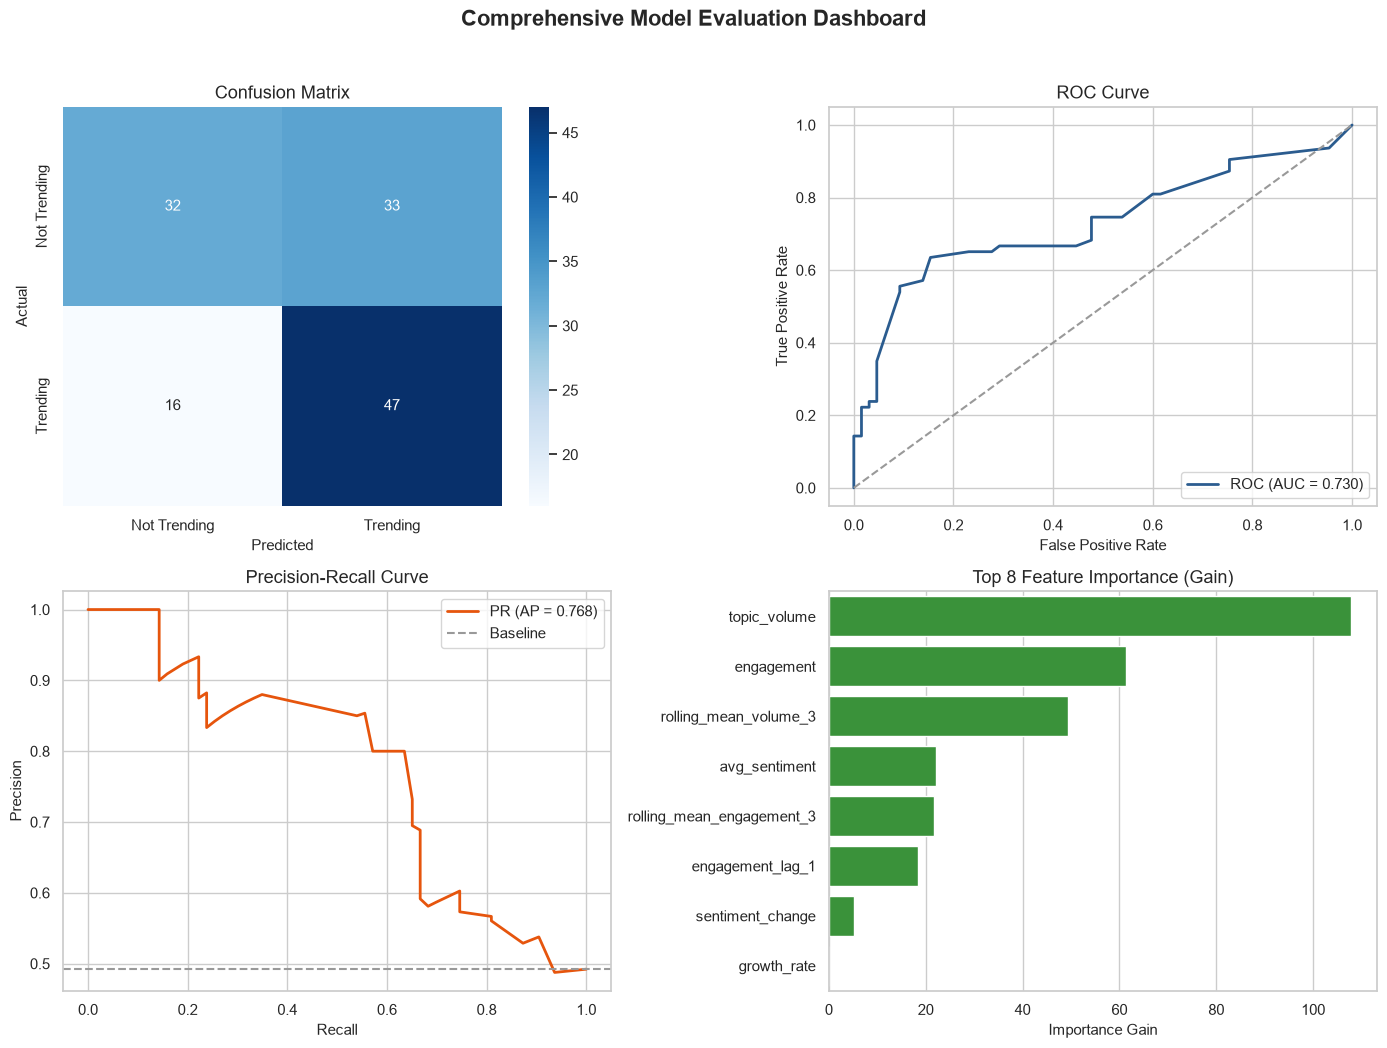

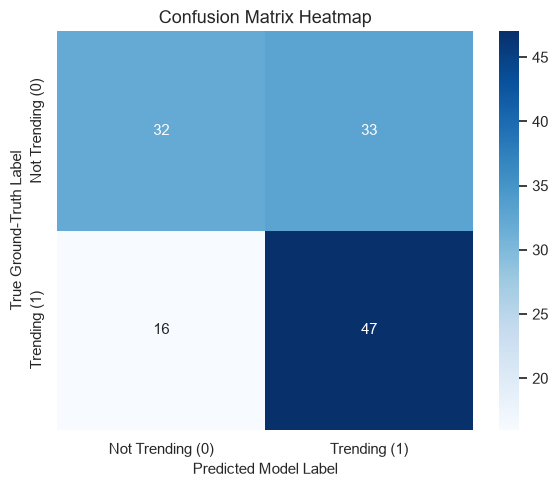

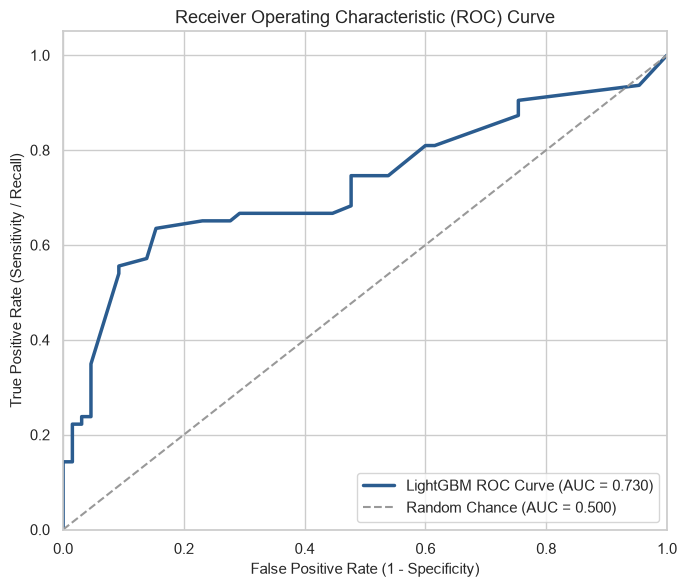

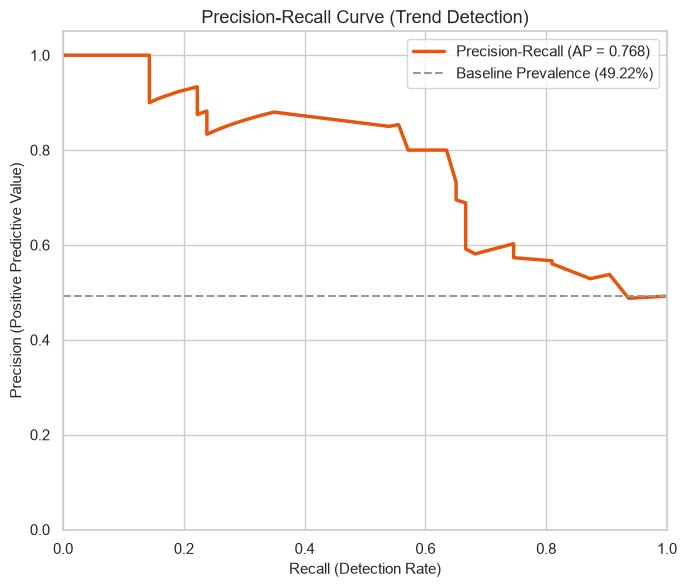

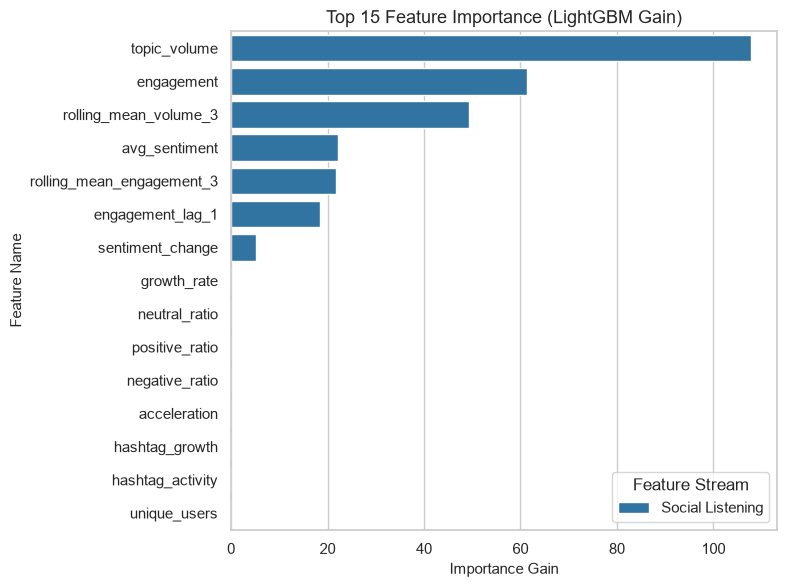

In [3]:
pipeline = PredictionPipeline(config.get('stage_08_prediction_models', {}))

# Run pipeline directly from chronological splits
trending_topics = pipeline.run_from_splits(splits_dir='../data/07_splits')

## 2. Visual Model Evaluation Plots

The functions below generate publication-grade visual evaluation charts:

(<Figure size 1400x1100 with 5 Axes>,
 array([[<Axes: title={'center': 'Confusion Matrix'}, xlabel='Predicted', ylabel='Actual'>,
         <Axes: title={'center': 'ROC Curve'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>],
        [<Axes: title={'center': 'Precision-Recall Curve'}, xlabel='Recall', ylabel='Precision'>,
         <Axes: title={'center': 'Calibration Curve'}, xlabel='Mean Predicted Prob', ylabel='Fraction Positives'>]],
       dtype=object))

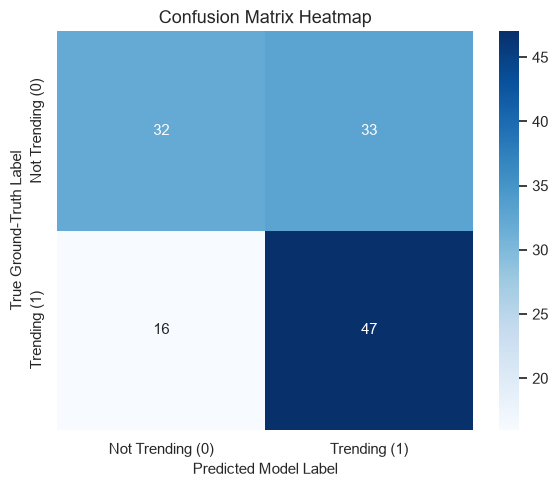

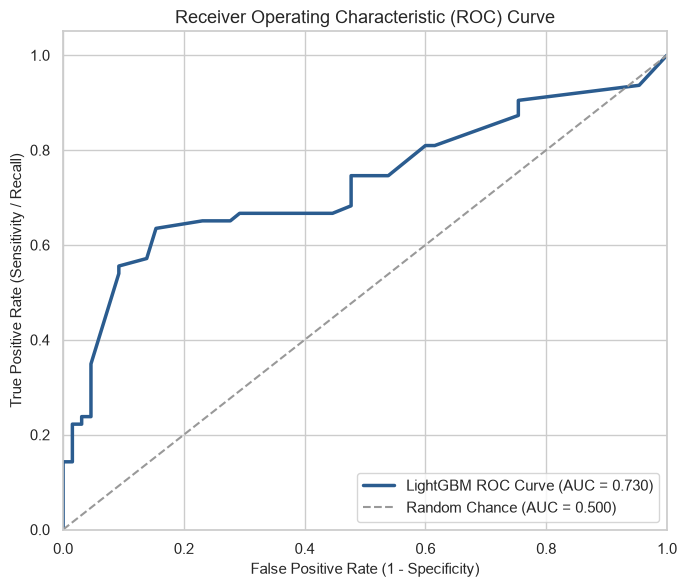

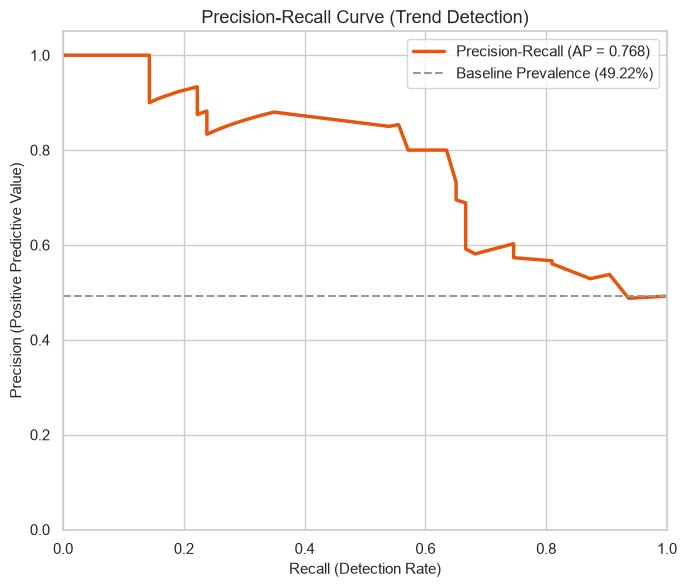

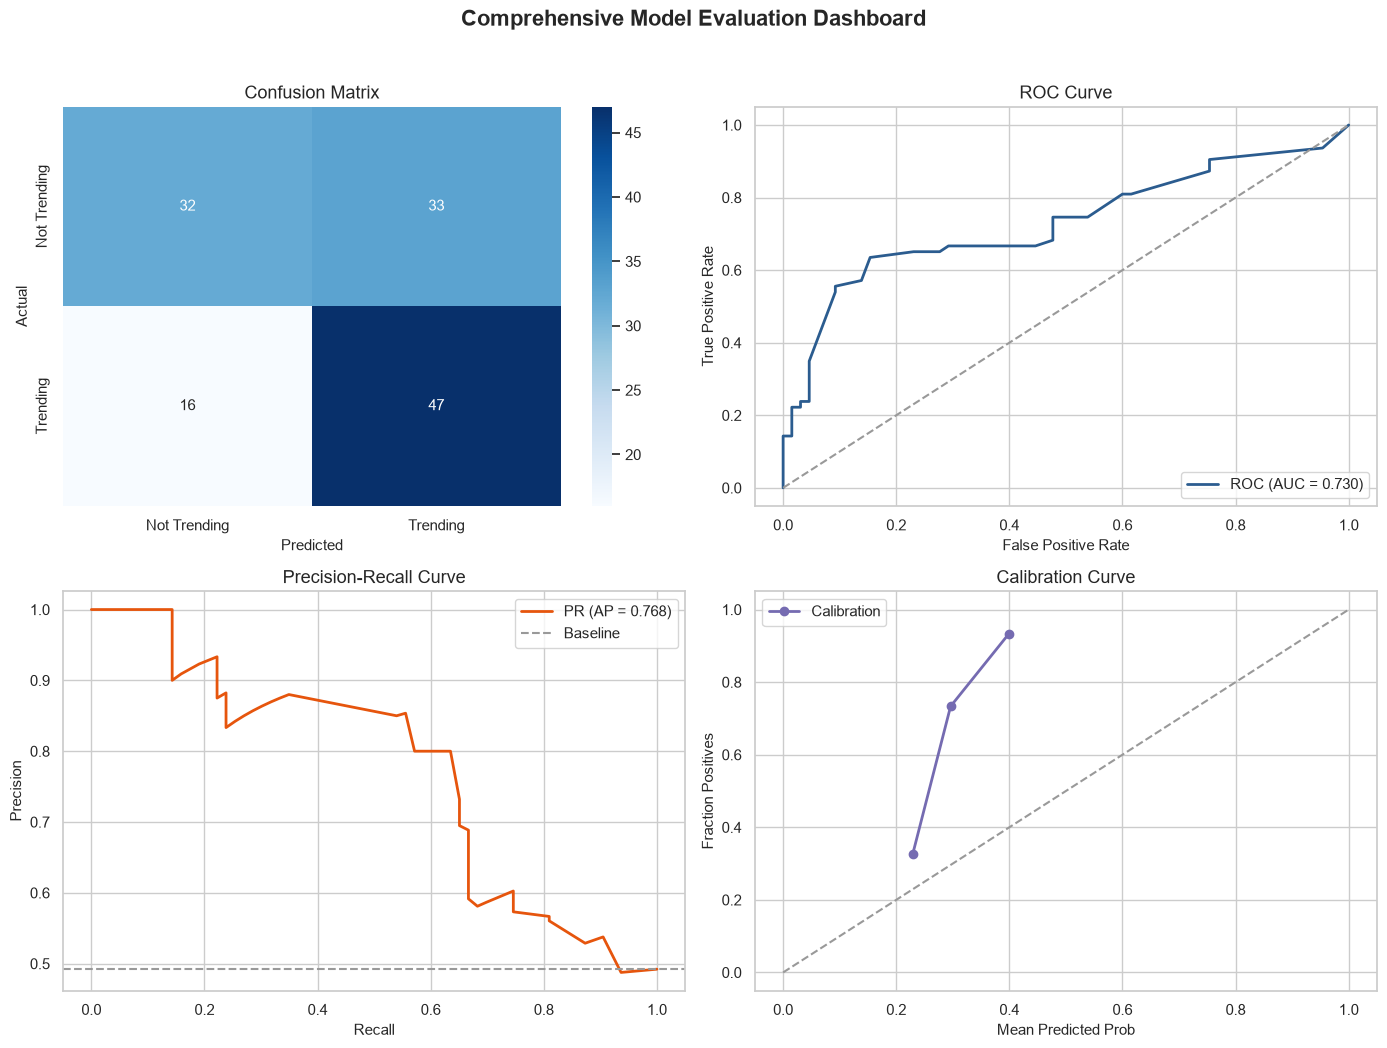

In [4]:
# Example: Generating and rendering evaluation figures
test_df = load_dataframe('../data/08_predictions/all_test_predictions.parquet')
y_true = test_df['is_trending'].values
y_pred = test_df['predicted_trending'].values
y_prob = test_df['trending_probability'].values

# 1. Confusion Matrix
plot_confusion_matrix(y_true, y_pred)

# 2. ROC Curve
plot_roc_curve(y_true, y_prob)

# 3. Precision-Recall Curve
plot_precision_recall_curve(y_true, y_prob)

# 4. Unified 4-Panel Evaluation Dashboard
plot_comprehensive_evaluation_grid(y_true, y_pred, y_prob)